In [48]:
import math
from PIL import Image, ImageDraw

# naloži sliko
img = Image.open("slika.jpg").convert("RGB")
width, height = img.size
draw = ImageDraw.Draw(img)

# parameter eksponentnega razpada
tau = 400        # časovna konstanta
amplitude = height

# eksponentna funkcija razpada
def exp_decay(t, tau):
    return math.exp(-t / tau)

points = []
for t in range(width):
    y = exp_decay(t, tau)
    y_pixel = int(2*height / 3 - amplitude * y+30)
    points.append((t+1300, y_pixel))

# nariši krivuljo
draw.line(points, fill=(255, 0, 0), width=5)

# shrani rezultat
img.save("slika_z_eksponentnim_razpadom.jpg")
img.show()


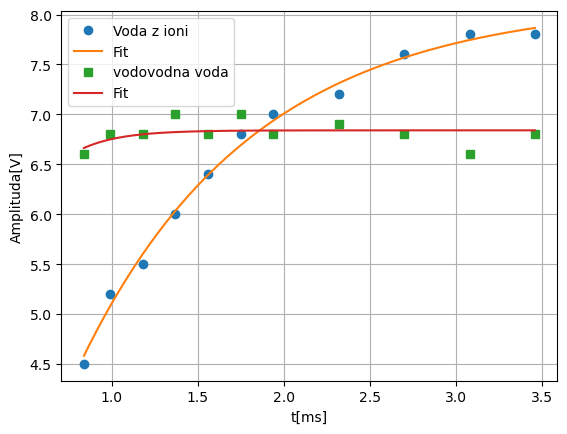

[6.8398476  0.22926845] [8.13085202 1.01074305]


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Podatki
N = np.array([1, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70])*0.038+0.8
amplituda = np.array([4.5, 5.2, 5.5, 6.0, 6.4, 6.8, 7.0, 7.2, 7.6, 7.8, 7.8])
A = np.array([6.6, 6.8, 6.8, 7.0, 6.8, 7.0, 6.8, 6.9, 6.8, 6.6, 6.8])

# Modelna funkcija
def model(t, M0, T1):
    return M0 * (1 - np.exp(-t / T1))

# Fit za oba niza podatkov
popt_amp, _ = curve_fit(model, N, amplituda, p0=(8, 20))
popt_A, _ = curve_fit(model, N, A, p0=(7, 20))

# Gladka os za risanje fitov
t_fit = np.linspace(N.min(), N.max(), 300)

# Risanje
plt.figure()
plt.plot(N, amplituda, 'o', label='Voda z ioni')
plt.plot(t_fit, model(t_fit, *popt_amp), '-', 
         label=f'Fit')

plt.plot(N, A, 's', label='vodovodna voda')
plt.plot(t_fit, model(t_fit, *popt_A), '-', 
         label=f'Fit')

plt.xlabel(r't[ms]')
plt.ylabel('Amplituda[V]')
plt.legend()
plt.grid(True)
plt.savefig("T1.pdf")
plt.show()
print(popt_A, popt_amp)


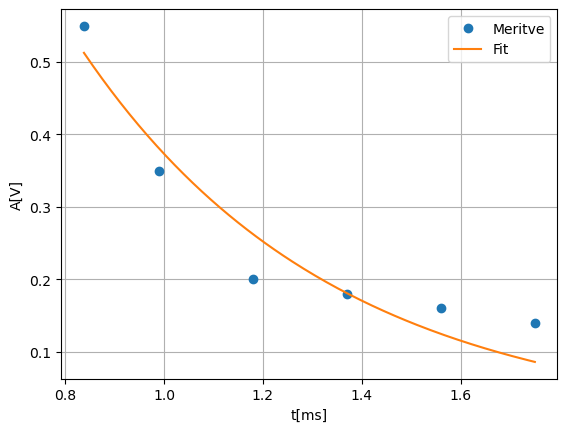

[2.65110261 0.51009568]


<Figure size 640x480 with 0 Axes>

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Podatki
N = np.array([1, 5, 10, 15, 20, 25])*0.038+0.8
A = np.array([0.55, 0.35, 0.20, 0.18, 0.16, 0.14])

# Eksponentna funkcija
def exp_decay(t, A0, T2):
    return A0 * np.exp(-t / T2)

# Fit
popt, pcov = curve_fit(exp_decay, N, A, p0=(0.6, 10))
A0_fit, T2_fit = popt

# Gladka os za fit
N_fit = np.linspace(N.min(), N.max(), 200)
A_fit = exp_decay(N_fit, A0_fit, T2_fit)

# Risanje
plt.figure()
plt.plot(N, A, 'o', label='Meritve')
plt.plot(N_fit, A_fit, '-', label=f'Fit')
plt.xlabel('t[ms]')
plt.ylabel('A[V]')
#plt.title('Eksponentni fit A = A0 · exp(-N/T2)')
plt.grid(True)
plt.legend()
plt.show()
plt.savefig("T2.pdf")
print(popt)
